In [1]:
# Data Cleaning & Visualization Project
# This project performs Exploratory Data Analysis (EDA) on the Sample Superstore dataset.
# The goal is to clean the dataset, analyze patterns, and visualize business insights.

In [2]:
# importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
FILE_PATH       = r"C:\Users\M JANEESHA REDDY\Desktop\Thiranex-1\SampleSuperstore.csv"  #Dataset

# scatter plot
SCATTER_X_COL   = "Discount"               # x-axis 
SCATTER_Y_COL   = "Profit"                 # y-axis 

# box plot & bar chart
GROUP_COL       = "Category"              

# box plot
BOX_COL         = "Sales"                  

# Output 
OUTPUT_PATH     = "dashboard.png"

In [4]:
## Data Cleaning
# Steps performed:
# - Removed duplicate rows
# - Cleaned text columns
# - Handled missing values
# - Clipped extreme outliers

In [5]:
# 1. LOAD DATASET
if FILE_PATH.endswith(".xlsx") or FILE_PATH.endswith(".xls"):
    df = pd.read_excel(FILE_PATH)
else:
    df = pd.read_csv(FILE_PATH)
    
print(f" Loaded: {df.shape[0]} rows × {df.shape[1]} cols")
print(f"\nColumns: {list(df.columns)}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nDuplicates: {df.duplicated().sum()}")

 Loaded: 9993 rows × 13 cols

Columns: ['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount', 'Profit']

Missing values:
Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

Duplicates: 17


In [6]:
# 2. DATA CLEANING

cleaning_log = {}
raw_shape = df.shape

# Remove duplicates
before = len(df)
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
cleaning_log['Duplicates removed'] = before - len(df)

# Standardise string columns (strip whitespace, fix case)
str_cols = df.select_dtypes(include='object').columns
for col in str_cols:
    df[col] = df[col].str.strip().str.title()
cleaning_log['String cols cleaned'] = len(str_cols)

# Clip outliers using IQR (only numeric cols)
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
outlier_count = 0
for col in num_cols:
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 3 * iqr, q3 + 3 * iqr
    clipped = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_count += clipped
    df[col] = df[col].clip(lower=lower, upper=upper)
cleaning_log['Outliers clipped'] = int(outlier_count)

# missing values
# Numeric--> median per group (if GROUP_COL exists), else overall median
#   Categorical -->  mode
for col in num_cols:
    if df[col].isnull().sum() > 0:
        if GROUP_COL in df.columns:
            df[col].fillna(
                df.groupby(GROUP_COL)[col].transform('median'), inplace=True)
        df[col].fillna(df[col].median(), inplace=True)

for col in str_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)

cleaning_log['Remaining nulls'] = int(df.isnull().sum().sum())
clean_shape = df.shape

print(f"\n Cleaned: {clean_shape[0]} rows × {clean_shape[1]} cols")
print("Cleaning log:", cleaning_log)




 Cleaned: 9976 rows × 13 cols
Cleaning log: {'Duplicates removed': 17, 'String cols cleaned': 8, 'Outliers clipped': 1836, 'Remaining nulls': 0}


In [7]:
## Data Visualization
# The dashboard below shows insights such as:
# - Sales distribution by category
# - Discount vs profit relationship
# - Category-level sales patterns
# - Feature correlations

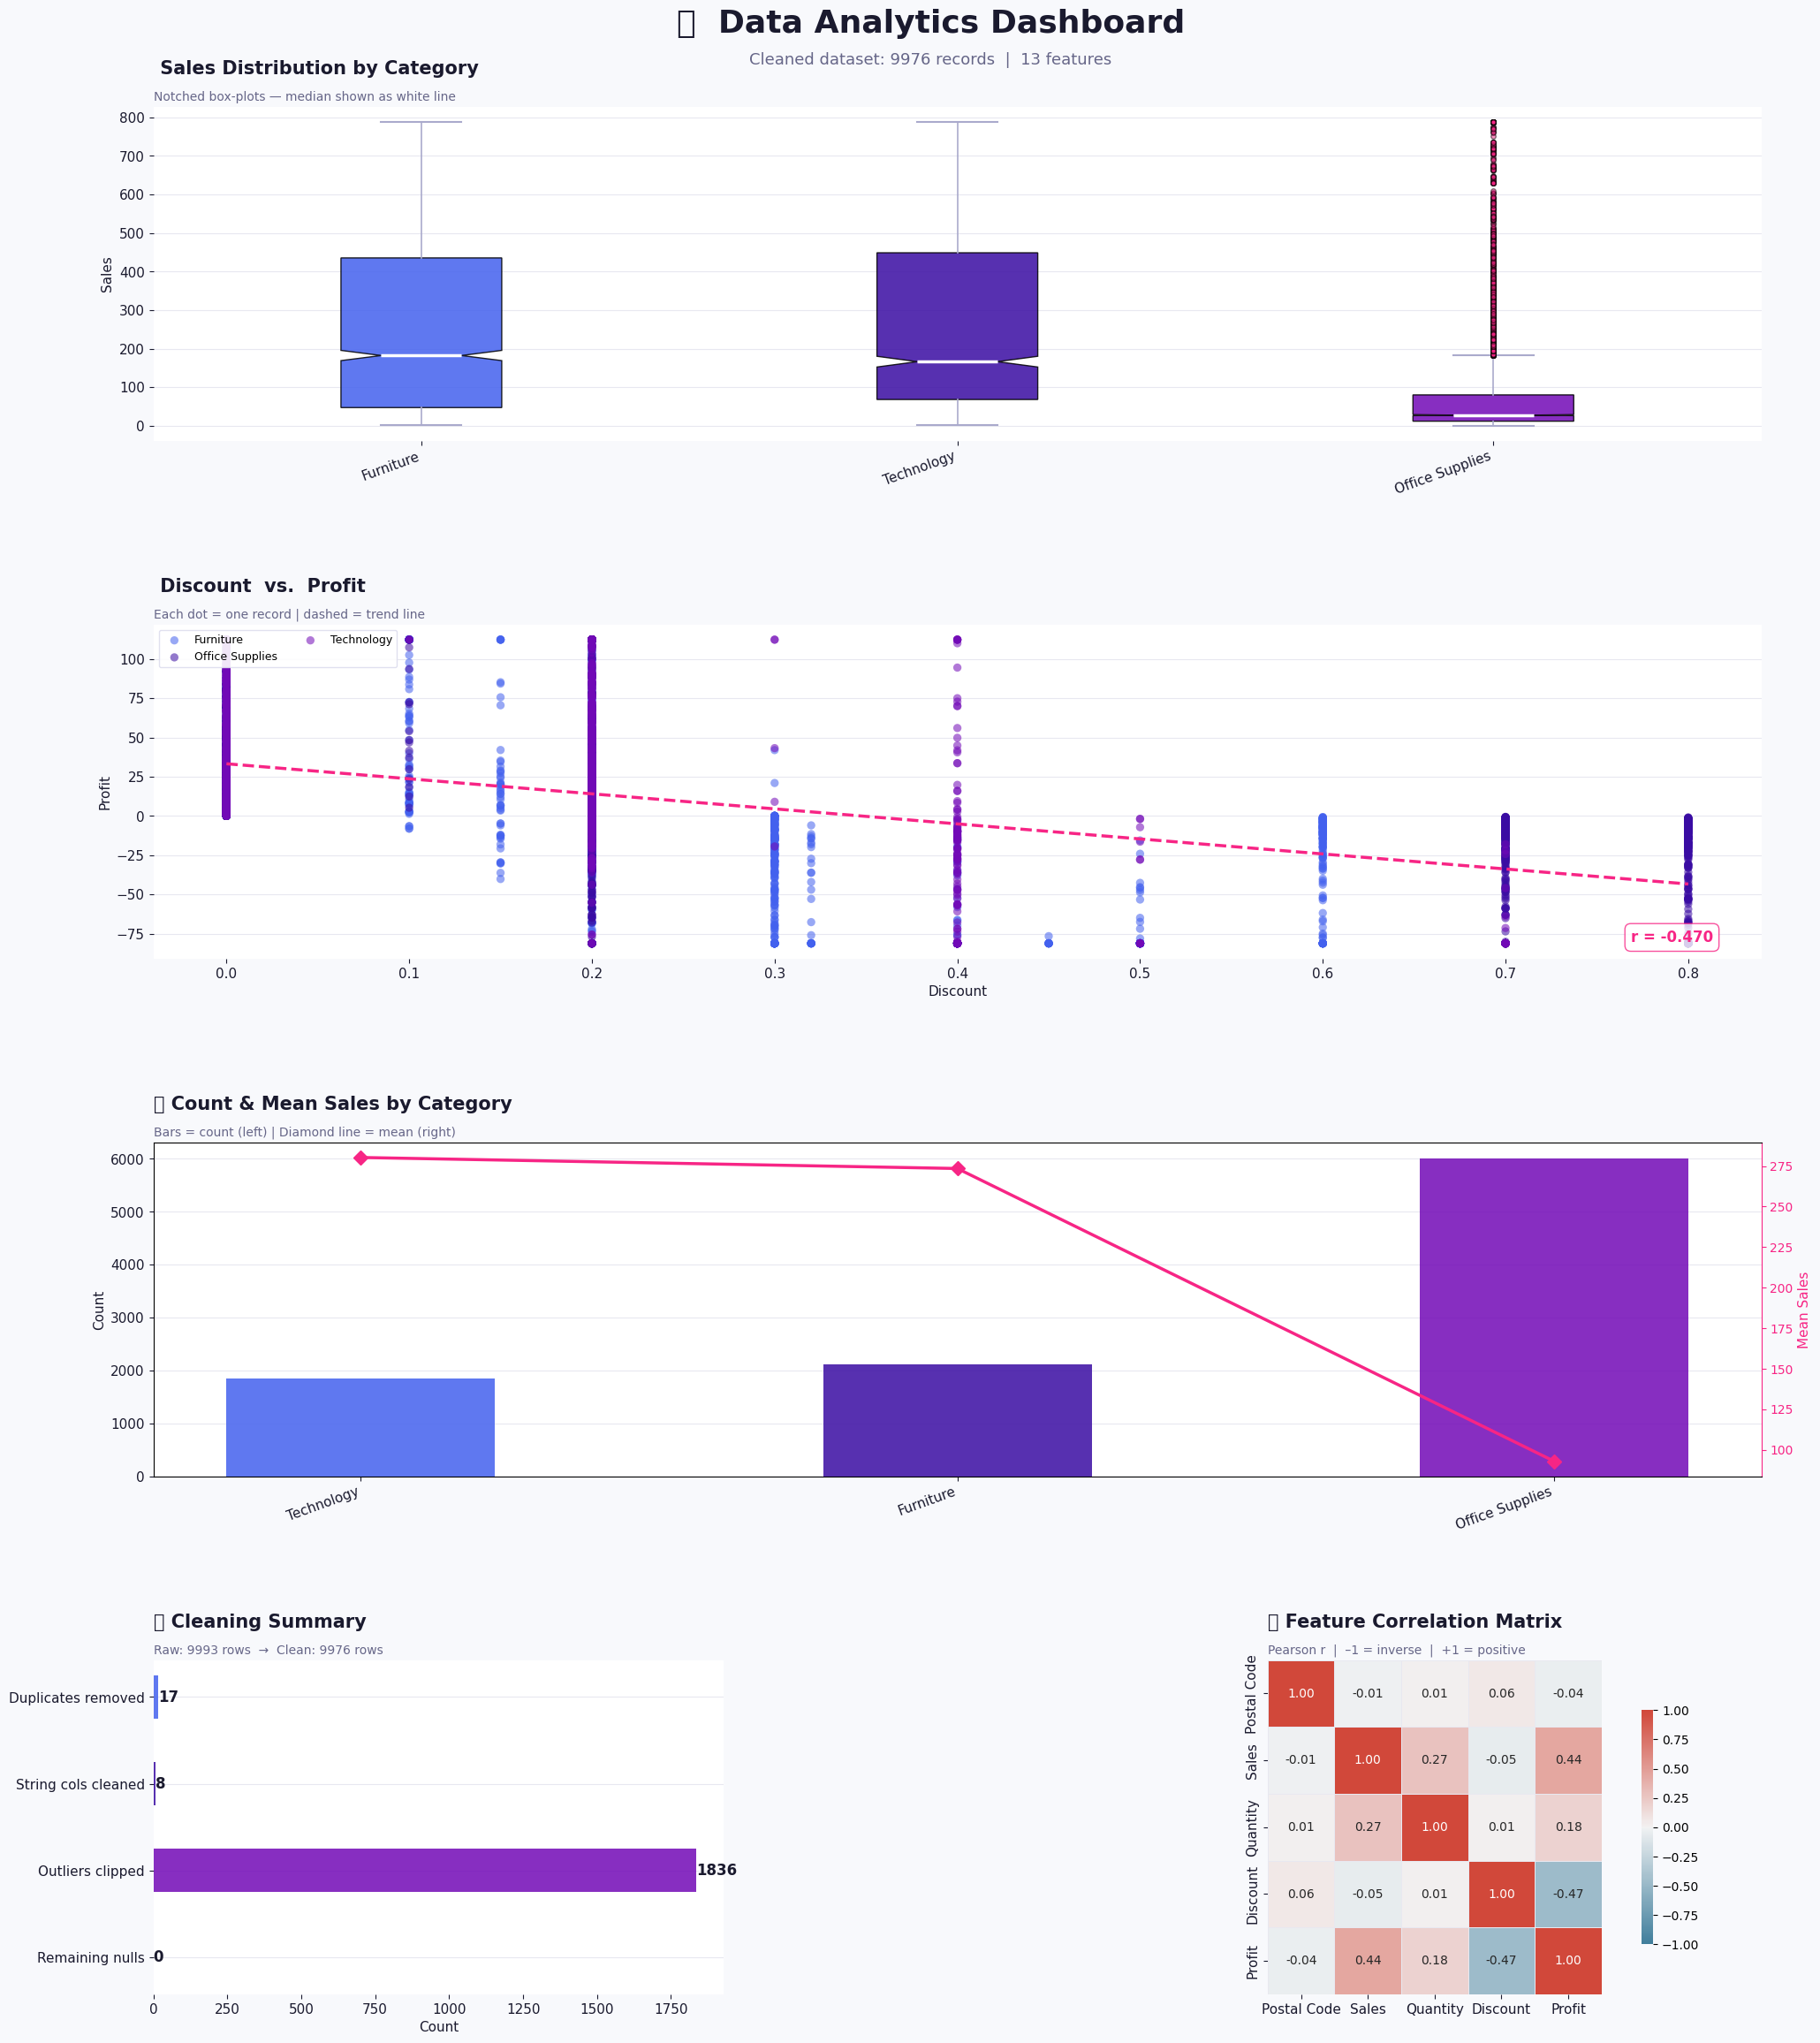

In [8]:
# 3. VISUALISATION
%matplotlib inline
PALETTE   = ['#4361EE','#3A0CA3','#7209B7','#F72585','#4CC9F0','#4895EF',
             '#560BAD','#480CA8','#B5179E','#F3722C']
BG        = '#F8F9FC'
CARD      = '#FFFFFF'
TEXT_DARK = '#1A1A2E'

fig = plt.figure(figsize=(20, 24), facecolor=BG)
outer = gridspec.GridSpec(4, 1, figure=fig,
    hspace=0.55, top=0.93, bottom=0.04, left=0.06, right=0.97)

def style_ax(ax, title, subtitle=''):
    ax.set_facecolor(CARD)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(colors=TEXT_DARK, labelsize=11)
    ax.set_title(f'{title}\n', fontsize=15, fontweight='bold',
                 color=TEXT_DARK, loc='left', pad=10)
    if subtitle:
        ax.text(0, 1.01, subtitle, transform=ax.transAxes,
                fontsize=10, color='#666688', va='bottom')
    ax.yaxis.grid(True, color='#E8E8F0', linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)

groups = df[GROUP_COL].dropna().unique() if GROUP_COL in df.columns else []
pal    = PALETTE[:len(groups)]

# Box plot 
ax1 = fig.add_subplot(outer[0])
if GROUP_COL in df.columns and BOX_COL in df.columns:
    group_order = (df.groupby(GROUP_COL)[BOX_COL]
                   .median().sort_values(ascending=False).index)
    bp = ax1.boxplot(
        [df[df[GROUP_COL]==g][BOX_COL].dropna() for g in group_order],
        labels=group_order, patch_artist=True, notch=True,
        medianprops=dict(color='white', linewidth=2.5),
        whiskerprops=dict(color='#AAAACC', linewidth=1.2),
        capprops=dict(color='#AAAACC', linewidth=1.5),
        flierprops=dict(marker='o', markerfacecolor='#F72585',
                        markersize=4, alpha=0.5, linestyle='none'))
    for patch, color in zip(bp['boxes'], PALETTE):
        patch.set_facecolor(color); patch.set_alpha(0.85)
    ax1.set_xticklabels(group_order, rotation=20, ha='right')
style_ax(ax1, f' {BOX_COL} Distribution by {GROUP_COL}',
         'Notched box-plots — median shown as white line')
ax1.set_ylabel(BOX_COL, color=TEXT_DARK, fontsize=11)

# Scatter plot 
ax2 = fig.add_subplot(outer[1])
if SCATTER_X_COL in df.columns and SCATTER_Y_COL in df.columns:
    if GROUP_COL in df.columns:
        for i, g in enumerate(groups):
            sub = df[df[GROUP_COL] == g]
            ax2.scatter(sub[SCATTER_X_COL], sub[SCATTER_Y_COL],
                        c=PALETTE[i % len(PALETTE)], label=str(g),
                        alpha=0.55, s=45, edgecolors='none')
        ax2.legend(loc='upper left', framealpha=0.9, fontsize=9,
                   ncol=2, edgecolor='#DDDDEE')
    else:
        ax2.scatter(df[SCATTER_X_COL], df[SCATTER_Y_COL],
                    c=PALETTE[0], alpha=0.55, s=45, edgecolors='none')

    # Trend line
    clean = df[[SCATTER_X_COL, SCATTER_Y_COL]].dropna()
    if len(clean) > 2:
        from numpy.polynomial.polynomial import polyfit
        b, m = polyfit(clean[SCATTER_X_COL], clean[SCATTER_Y_COL], 1)
        xs   = np.linspace(clean[SCATTER_X_COL].min(),
                           clean[SCATTER_X_COL].max(), 100)
        ax2.plot(xs, m*xs + b, color='#F72585', lw=2.5,
                 linestyle='--', label='Trend', zorder=5)
        corr = clean[SCATTER_X_COL].corr(clean[SCATTER_Y_COL])
        ax2.text(0.97, 0.05, f'r = {corr:.3f}',
                 transform=ax2.transAxes, ha='right', fontsize=12,
                 color='#F72585', fontweight='bold',
                 bbox=dict(boxstyle='round,pad=0.4',
                           fc='white', ec='#F72585', alpha=0.8))
ax2.set_xlabel(SCATTER_X_COL, color=TEXT_DARK, fontsize=11)
ax2.set_ylabel(SCATTER_Y_COL, color=TEXT_DARK, fontsize=11)
style_ax(ax2, f' {SCATTER_X_COL}  vs.  {SCATTER_Y_COL}',
         'Each dot = one record | dashed = trend line')

# ── Chart 3: Grouped bar + line 
ax3a = fig.add_subplot(outer[2])
ax3b = ax3a.twinx()
if GROUP_COL in df.columns and BOX_COL in df.columns:
    stats = (df.groupby(GROUP_COL)
               .agg(count=(BOX_COL,'count'), mean=(BOX_COL,'mean'))
               .sort_values('mean', ascending=False))
    x, w = np.arange(len(stats)), 0.45
    ax3a.bar(x, stats['count'], w, color=PALETTE[:len(stats)],
             alpha=0.85, zorder=3)
    ax3b.plot(x, stats['mean'], color='#F72585', marker='D',
              ms=8, lw=2.5, zorder=4)
    ax3a.set_xticks(x)
    ax3a.set_xticklabels(stats.index, rotation=20, ha='right', fontsize=11)
    ax3a.set_ylabel('Count',          color=TEXT_DARK, fontsize=11)
    ax3b.set_ylabel(f'Mean {BOX_COL}', color='#F72585', fontsize=11)
    ax3b.spines['right'].set_visible(True)
    ax3b.spines['right'].set_color('#F72585')
    ax3b.tick_params(axis='y', colors='#F72585')
style_ax(ax3a, f'🏢 Count & Mean {BOX_COL} by {GROUP_COL}',
         'Bars = count (left) | Diamond line = mean (right)')

# ── Chart 4: Cleaning log + Correlation ─
gs4  = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=outer[3],
                                        wspace=0.35, width_ratios=[1, 1.4])
ax4a = fig.add_subplot(gs4[0])
ax4b = fig.add_subplot(gs4[1])

steps  = list(cleaning_log.keys())
values = [max(v, 0) for v in cleaning_log.values()]
hbars  = ax4a.barh(steps, values, color=PALETTE[:len(steps)],
                   alpha=0.85, height=0.5)
for bar, val in zip(hbars, values):
    ax4a.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
              str(val), va='center', fontsize=12,
              fontweight='bold', color=TEXT_DARK)
ax4a.set_xlabel('Count', color=TEXT_DARK, fontsize=11)
style_ax(ax4a, '🧹 Cleaning Summary',
         f'Raw: {raw_shape[0]} rows  →  Clean: {clean_shape[0]} rows')
ax4a.invert_yaxis()

corr_cols = df.select_dtypes(include=[np.number]).columns[:6]
if len(corr_cols) >= 2:
    corr_mat = df[corr_cols].corr()
    sns.heatmap(corr_mat, ax=ax4b, annot=True, fmt='.2f',
                cmap=sns.diverging_palette(230, 15, as_cmap=True),
                vmin=-1, vmax=1, linewidths=0.5, linecolor='#E8E8F0',
                square=True, cbar_kws={'shrink': 0.7},
                xticklabels=[c.replace('_','\n') for c in corr_cols],
                yticklabels=[c.replace('_','\n') for c in corr_cols])
style_ax(ax4b, '🔗 Feature Correlation Matrix',
         'Pearson r  |  –1 = inverse  |  +1 = positive')

# ── Header ──────────────────────────────
fig.text(0.5, 0.965, '🔍  Data Analytics Dashboard',
         ha='center', fontsize=26, fontweight='bold', color=TEXT_DARK)
fig.text(0.5, 0.950,
         f'Cleaned dataset: {clean_shape[0]} records  |  {len(df.columns)} features',
         ha='center', fontsize=13, color='#666688')

plt.show()

In [9]:
## Key Insights
# 1. Technology and Furniture categories generate higher average sales compared to Office Supplies.
# 2. Higher discounts tend to reduce profit margins, indicating that aggressive discount strategies may hurt profitability.
# 3. Office Supplies have the highest order frequency but the lowest average sales value.